In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [21]:
data = load_wine()
x = data.data
y = data.target

df = pd.DataFrame(x, columns=data.feature_names)
print('-- Data Types --')
print(df.dtypes)
print('-- Describe --')
print(df.describe())

-- Data Types --
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
dtype: object
-- Describe --
          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.

In [22]:
# Standardizzazione

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)


In [23]:
# Riduzione Dimensioni

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

print(f'Varianza spiegata dalle componenti:\t{pca.explained_variance_}')
print(f'Varianza totale spiegata:\t{sum(pca.explained_variance_)}')

Varianza spiegata dalle componenti:	[4.73243698 2.51108093]
Varianza totale spiegata:	7.243517907228711


In [24]:
# KNN

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_pca, y)

# SVM

svm = SVC(kernel='linear')
svm.fit(x_pca, y)

# Predizioni

y_pred_knn = knn.predict(x_pca)
y_pred_svm = svm.predict(x_pca)



In [25]:
# Accuracy

acc_knn = accuracy_score(y, y_pred_knn)
acc_svm = accuracy_score(y, y_pred_svm)

print(f'Accuracy KNN:\t{acc_knn:.4f}')
print(f'Accuracy SVM:\t{acc_svm:.4f}')

Accuracy KNN:	0.9663
Accuracy SVM:	0.9719


In [26]:
## Visualizzaione
# Griglia

x_min, x_max = x_pca[:,0].min() - 1, x_pca[:,0].max() + 1
y_min, y_max = x_pca[:,1].min() -1, x_pca[:,1].max() +1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))

# Predizioni Griglia

z_knn = knn.predict(np.c_[xx.ravel(), yy.ravel()])
z_knn = z_knn.reshape(xx.shape)

z_svm = svm.predict(np.c_[xx.ravel(), yy.ravel()])
z_svm = z_svm.reshape(xx.shape)


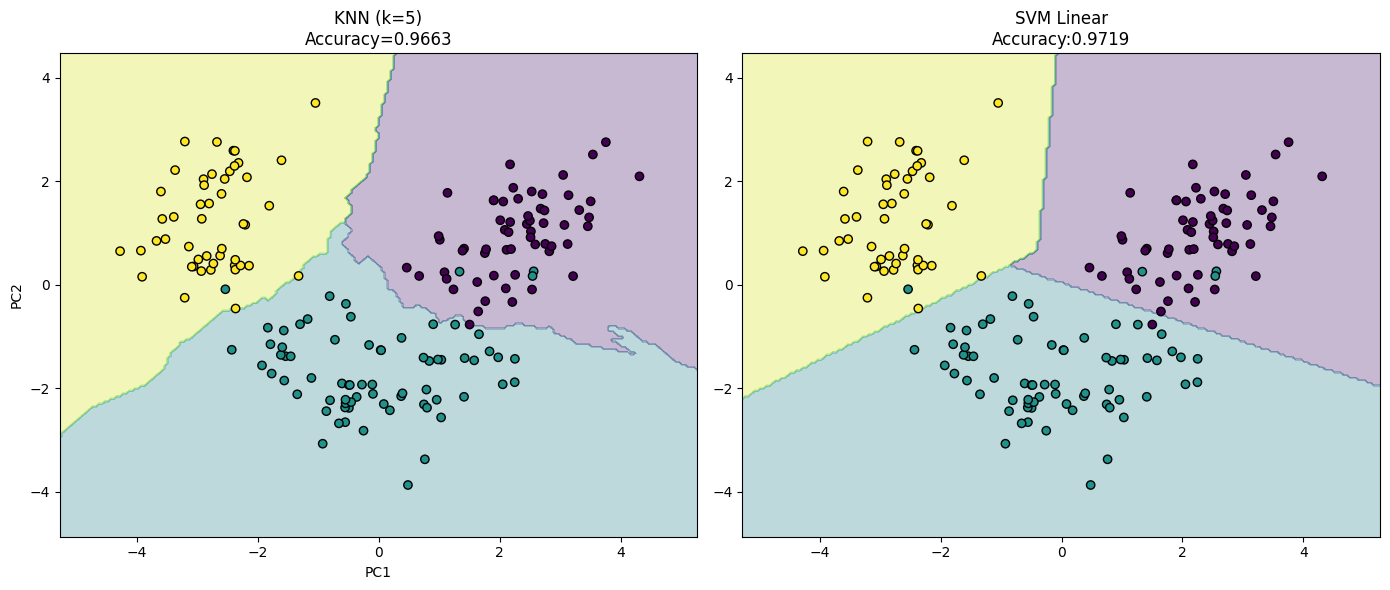

In [27]:
# Plot

fig, axes = plt.subplots(1,2, figsize=(14,6))

# KNN

axes[0].contourf( xx, yy, z_knn, alpha=0.3)

scatter1 = axes[0].scatter(x_pca[:,0], x_pca[:,1], c=y, edgecolor='k')
axes[0].set_title(f'KNN (k=5)\nAccuracy={acc_knn:.4f}')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# SVM

axes[1].contourf(xx, yy, z_svm, alpha=0.3)

scatter2 = axes[1].scatter(x_pca[:,0], x_pca[:,1], c=y, edgecolor='k')
axes[1].set_title(f'SVM Linear\nAccuracy:{acc_svm:.4f}')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

plt.tight_layout()
plt.show()